<a href="https://colab.research.google.com/github/tommypolpo/geron-hands_on_ML/blob/main/c3_bin_digits_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Chapter 3 of Geron's book. Classification systems

In [2]:
from sklearn.datasets import fetch_openml
mnist=fetch_openml("mnist_784", as_frame=False) #False to get the dataset as NumPy arrays
X,y=mnist.data, mnist.target
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [3]:
y

array(['5', '0', '4', ..., '4', '5', '6'], dtype=object)

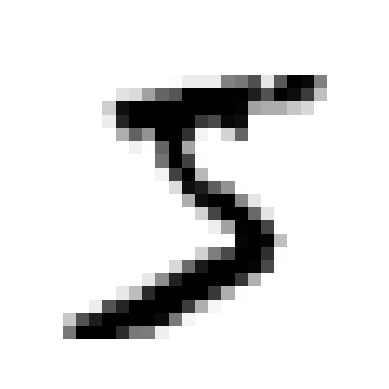

In [4]:
import matplotlib.pyplot as plt
def plot_digit(image_data):
  image = image_data.reshape(28,28)
  plt.imshow(image, cmap="binary")
  plt.axis("off")

some_digit=X[0]
plot_digit(some_digit)
plt.show()

In [5]:
#create a train set and a test set
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

#true for all 5 and false for all other digits
y_train_5 = (y_train == 5)
y_test_5 = (y_test == 5)

In [6]:
### A binary classifier that classifies what is 5 and what is not 5
from sklearn.linear_model import SGDClassifier
import numpy as np

# Re-create y_train_5 and y_test_5 with correct type conversion
y_train_5 = (y_train == "5")
y_test_5 = (y_test == "5")

sgd_clf = SGDClassifier(random_state=42)
#we train the classifier on the whole training set and the new true/false labels
sgd_clf.fit(X_train, y_train_5)

SGDClassifier(random_state=42)

In [7]:
#measure accuracy using cross validation
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

In [8]:
from sklearn import dummy
#This looks promising, however, compare to the following dummy classifier that simply
#classifies evry single image in the most frequent class, that is "non 5"
#so this classifier simply assigns to every image "non 5"
#since there are only about 10% of 5 in the training set, this dummy classifier is correct 90% of the time
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring="accuracy")


array([0.90965, 0.90965, 0.90965])

In [9]:
## Instead of computing directly the score of the mode, we first "save" the predictions

from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_train_5, y_train_pred)
cm



array([[53892,   687],
       [ 1891,  3530]])

There are two classes: not-5 and 5. The first row of the confusion matrix represent the non-5 images. The first number is True Negatives (correctly classified non-5), the second number is False Positives (non-5 images that has been classified as 5).
Similarly, the second line represents 5 images. The first number is False Negatives (5 that have been classified as non-5), the second number is True Positives (5 classified as 5).

In [10]:
#To simulate a perfect mode, we can replace the predicion from the model with the labels
y_train_perfect_predictions=y_train_5
confusion_matrix(y_train_5, y_train_perfect_predictions)

array([[54579,     0],
       [    0,  5421]])

In [11]:
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import f1_score
precision_score(y_train_5, y_train_pred) # precision: all correct 5 guesses over all 5 guesses (true positives + false positives)

0.8370879772350012

In [12]:
recall_score(y_train_5, y_train_pred) # recall: all correct 5 guesses over all 5 images (true positives + false negatives)

0.6511713705958311

In [13]:
f1_score(y_train_5, y_train_pred)

0.7325171197343847

In [14]:
## Instead of calling the classifier predict() method, we can can use the decision_function() method, which assings to each image (each instance)
## a score. Then, we can make all the predictions we want based on those
## here some_digit=X[0] (the first image in the database)
y_scores=sgd_clf.decision_function([some_digit])
y_scores

array([2164.22030239])

In [15]:
threshold =0
y_some_digit_pred = (y_scores>threshold)
y_some_digit_pred

array([ True])

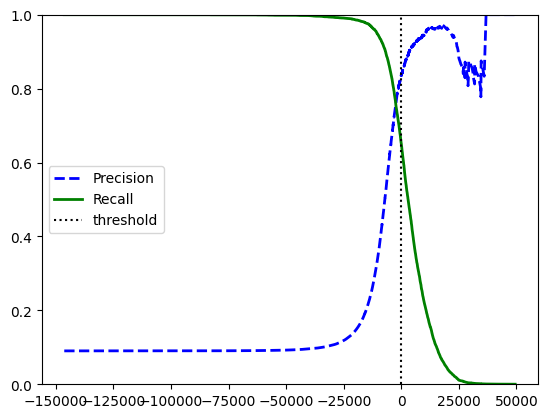

In [16]:
## How to decide with threshold to use? plot the precision and recall as a function of the threshold
y_scores=cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, method="decision_function")

from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(threshold, 0, 1.0, "k", "dotted", label="threshold")
plt.legend(loc="center left")
plt.ylim([0,1])
plt.show()

In [17]:
#we can use this plot to estimate the threshold needed to achieve e.g. 90% precision, or we use an argmax method
idx_for_90_precision=(precisions>=0.90).argmax()
threshold_for_90_precision=thresholds[idx_for_90_precision]
threshold_for_90_precision

np.float64(3370.0194991439557)

In [18]:
#Check, the precision of this prediction with this threshold is in fact 90%
y_train_pred_90=(y_scores>=threshold_for_90_precision)
precision_score(y_train_5, y_train_pred_90)

0.9000345901072293

In [19]:
recall_at_90_precision=recall_score(y_train_5, y_train_pred_90)
recall_at_90_precision

0.4799852425751706

In [20]:
#let's now explore another model: RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
forest_clf=RandomForestClassifier(random_state=42)
y_probas_forest=cross_val_predict(forest_clf, X_train, y_train_5, cv=3, method="predict_proba")
y_probas_forest[:2] ## let's look at the first two images.
#the first image has probability 0.89 of being in the positive class (5)

array([[0.11, 0.89],
       [0.99, 0.01]])

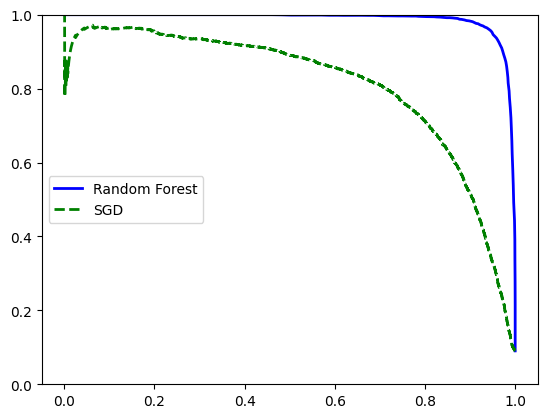

In [21]:
y_scores_forest=y_probas_forest[:,1] # just look at the probability to be in the positive class, and use that as a score
precisions_forest, recalls_forest, thresholds_forest = precision_recall_curve(y_train_5, y_scores_forest)

plt.plot(recalls_forest, precisions_forest, "b-", linewidth=2, label="Random Forest")
plt.plot(recalls, precisions, "g--", linewidth=2, label="SGD") ### SGD method, recalls and precisious computed before
plt.legend(loc="center left")
plt.ylim([0,1])
plt.show()



In [22]:
### the Random Forest Classifier using 0.5 as a threshold
y_train_pred_forest=y_scores_forest>=0.5  ## assuming positive class (5) if probability >=50%
precision_score(y_train_5, y_train_pred_forest)

0.9897468089558485

In [23]:
recall_score(y_train_5, y_train_pred_forest)

0.8725327430363402

In [24]:
f1_score(y_train_5, y_train_pred_forest)

0.9274509803921569

MULTICLASS CLASSIFICATION

In [25]:
#Sciki-Learn uses a One vs One strategy and trains binary classifiers
from sklearn.svm import SVC
svm_clf=SVC(random_state=42)
svm_clf.fit(X_train[:2000], y_train[:2000])

#we can use this to predict what's the value of some_digit=X[0]
svm_clf.predict([some_digit])

SVC(random_state=42)

In [30]:
#we can actually see the scores the 10 scores for each class using the decision_function() method
some_digits_score=svm_clf.decision_function([some_digit])
some_digits_score.round(2)
# the highest score is 9.3 corresponding (correctly) to the "5" class


array([[ 3.79,  0.73,  6.06,  8.3 , -0.29,  9.3 ,  1.75,  2.77,  7.21,
         4.82]])

In [31]:
#training an SGDClassifier is just as easy:
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train)
sgd_clf.predict([some_digit])
#it predicts "3", it is wrong but mistakes happen

array(['3'], dtype='<U1')

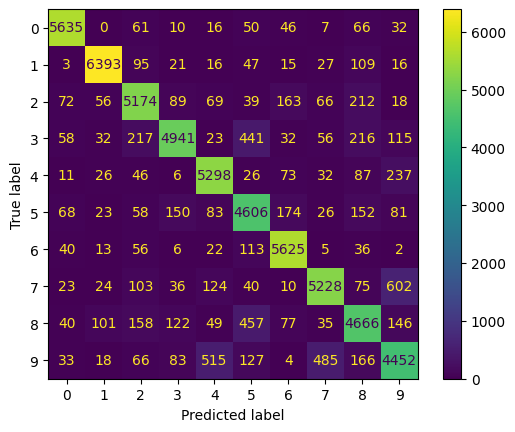

In [32]:
#in order to look at the confusion matrix we need the cross_val_predict() function
#also, a colored matrix is easier to read
from sklearn.metrics import ConfusionMatrixDisplay

y_train_pred=cross_val_predict(sgd_clf, X_train, y_train, cv=3)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred)
plt.show()


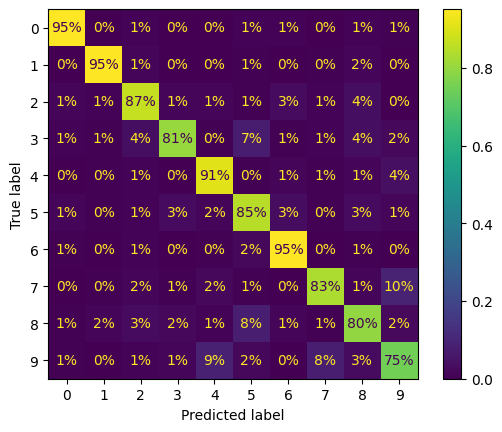

In [34]:
#Normalize the confusion matrix by dividing each value by the number of images in the corresponding class
#that is, dividing the row's sum (remember, row 0 corresponds to all the images of 0, the columns are the predictions)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, normalize="true", values_format=".0%")